In [4]:
import geopandas as gpd
import pandas as pd
import fiona

gpkg_path = r"C:\SoilGrids\data\Ubicacion_Estacion Principal.gpkg"
layers = fiona.listlayers(gpkg_path)

records = []
source_crs = None

for layer_name in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer_name)
    if gdf.empty:
        continue

    point_rows = gdf[gdf.geometry.geom_type.isin(["Point", "MultiPoint"])].copy()
    if point_rows.empty:
        continue

    source_crs = gdf.crs
    point_rows["x"] = point_rows.geometry.x
    point_rows["y"] = point_rows.geometry.y
    point_rows["layer"] = layer_name

    if source_crs is not None:
        point_rows_wgs84 = point_rows.to_crs(4326)
        point_rows["longitude"] = point_rows_wgs84.geometry.x
        point_rows["latitude"] = point_rows_wgs84.geometry.y
    else:
        point_rows["longitude"] = pd.NA
        point_rows["latitude"] = pd.NA

    records.append(point_rows[["layer", "x", "y", "longitude", "latitude", "geometry"]])

if not records:
    raise ValueError("No point geometries were found in the geopackage.")

coords_df = pd.concat(records, ignore_index=True)
print(f"Layers: {list(layers)}")
print(f"Source CRS: {source_crs}")
coords_df

Layers: ['Ubicacion_Estacion Principal']
Source CRS: EPSG:24877


,layer,x,y,longitude,latitude,geometry
0,Ubicacion_Estacion Principal,696444.80038,9.661710e+06,-79.234636,-3.062424,POINT (696444.8 9661710.265)


In [1]:
import pandas as pd
import numpy as np

# Load TDR data
tdr_path = r"TDR_data\TDR_ladera_zhurucay_2021_09_2026_03.csv"
df_tdr = pd.read_csv(tdr_path, parse_dates=["TIMESTAMP"])

# Drop duplicate timestamps if any
df_tdr = df_tdr.drop_duplicates(subset="TIMESTAMP")

# Set TIMESTAMP as index and resample to daily mean
df_tdr = df_tdr.set_index("TIMESTAMP")
df_day = df_tdr.resample("D").mean()
df_day.index.name = "Date"

# Save daily averages to a new CSV
output_path = r"TDR_data\TDR_ladera_zhurucay_daily_avg.csv"
df_day.to_csv(output_path)

print(f"Daily averages saved to: {output_path}")
print(f"Shape: {df_day.shape}")
df_day.head()


Daily averages saved to: TDR_data\TDR_ladera_zhurucay_daily_avg.csv
Shape: (1659, 12)


,VW_Avg(14),VW_Avg(15),VW_Avg(16),VW_Avg(17),VW_Avg(18),VW_Avg(19),VW_Avg(20),VW_Avg(21),VW_Avg(22),VW_Avg(23),VW_Avg(24),VW_Avg(25)
Date,,,,,,,,,,,,
2021-09-10,0.732906,0.702226,0.726562,0.692944,0.734441,0.762181,0.705681,0.363260,0.678861,0.722021,0.661292,0.819569
2021-09-11,0.733330,0.715705,0.727122,0.691111,0.739132,0.762163,0.706198,0.361917,0.681104,0.722816,0.661615,0.824972
2021-09-12,0.740552,0.736747,0.740740,0.713205,0.751632,0.772743,0.720292,0.394344,0.700215,0.733312,0.696274,0.837531
2021-09-13,0.768399,0.747740,0.757146,0.743052,0.759663,0.778705,0.721969,0.399878,0.707507,0.733139,0.687767,0.836868
2021-09-14,0.759649,0.722806,0.740396,0.729174,0.748774,0.770851,0.712701,0.375840,0.686802,0.728819,0.672569,0.826424


In [2]:
# Compute the mean across all sensors for each day
df_day_mean = df_day.mean(axis=1).rename("VW_mean_all_sensors").to_frame()
df_day_mean.index.name = "Date"

# Save to CSV
output_mean_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
df_day_mean.to_csv(output_mean_path)

print(f"Saved to: {output_mean_path}")
print(f"Shape: {df_day_mean.shape}")
df_day_mean.head()


Saved to: TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv
Shape: (1659, 1)


,VW_mean_all_sensors
Date,
2021-09-10,0.691829
2021-09-11,0.693932
2021-09-12,0.711466
2021-09-13,0.720153
2021-09-14,0.706234


In [16]:
import pandas as pd

# Find missing dates in daily mean soil moisture series
daily_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
df_daily = pd.read_csv(daily_path, parse_dates=["Date"])

df_daily = df_daily.drop_duplicates(subset="Date").sort_values("Date")
df_daily = df_daily.set_index("Date")

full_days = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq="D")

# A date is missing if it is absent from the index OR present but value is NaN
missing_from_index = full_days.difference(df_daily.index)
nan_days = df_daily.index[df_daily["VW_mean_all_sensors"].isna()]
all_missing_days = pd.DatetimeIndex(sorted(set(missing_from_index).union(set(nan_days))))

missing_dates_df = pd.DataFrame({"date": all_missing_days.date})
out_missing_dates = r"resultados\missing_dates_daily_mean_all_sensors.csv"
missing_dates_df.to_csv(out_missing_dates, index=False)

# Build summary of consecutive missing-date gaps
gap_rows = []
if len(all_missing_days) > 0:
    s = pd.Series(all_missing_days)
    group_id = (s.diff().dt.days.ne(1)).cumsum()

    for _, grp in s.groupby(group_id):
        start = grp.iloc[0]
        end = grp.iloc[-1]
        length_days = len(grp)
        gap_rows.append({
            "start_date": start.date(),
            "end_date": end.date(),
            "length_days": int(length_days)
        })

gaps_df = pd.DataFrame(gap_rows).sort_values("length_days", ascending=False) if gap_rows else pd.DataFrame(columns=["start_date", "end_date", "length_days"])
out_gaps_summary = r"resultados\missing_gaps_summary_daily_mean_all_sensors.csv"
gaps_df.to_csv(out_gaps_summary, index=False)

print("Missing-date audit complete for daily mean CSV")
print(f"Date range checked: {full_days.min().date()} to {full_days.max().date()}")
print(f"Missing from index: {len(missing_from_index)}")
print(f"NaN days in VW_mean_all_sensors: {len(nan_days)}")
print(f"Total unique missing dates: {len(all_missing_days)}")
print(f"Saved missing dates to: {out_missing_dates}")
print(f"Saved gap summary to: {out_gaps_summary}")

if len(all_missing_days) > 0:
    print("\nFirst 30 missing dates:")
    print(pd.Series(all_missing_days.date).head(30).to_string(index=False))

if len(gaps_df) > 0:
    print("\nTop 10 largest consecutive missing-date gaps:")
    print(gaps_df.head(10).to_string(index=False))

gaps_df.head(10)

ParserError: Error tokenizing data. C error: Expected 2 fields in line 1156, saw 3


In [13]:
import pandas as pd

# Remove dates with missing data and store clean result in a dataframe
daily_path = r"TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv"
missing_dates_path = r"resultados\missing_dates_daily_mean_all_sensors.csv"

df_daily_full = pd.read_csv(daily_path, parse_dates=["Date"])
missing_dates_df = pd.read_csv(missing_dates_path, parse_dates=["date"])

# Normalize date columns (date-only, no time component)
df_daily_full["Date"] = pd.to_datetime(df_daily_full["Date"]).dt.normalize()
missing_date_set = set(pd.to_datetime(missing_dates_df["date"]).dt.normalize())

# Drop rows that are in the missing-date list and ensure target variable is not NaN
df_daily_clean = df_daily_full[~df_daily_full["Date"].isin(missing_date_set)].copy()
df_daily_clean = df_daily_clean.dropna(subset=["VW_mean_all_sensors"])
df_daily_clean = df_daily_clean.sort_values("Date").reset_index(drop=True)

# Optional: save cleaned dataset for downstream analysis
clean_out_path = r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv"
df_daily_clean.to_csv(clean_out_path, index=False)

print("Clean dataframe created")
print(f"Original rows: {len(df_daily_full)}")
print(f"Missing dates removed: {len(missing_date_set)}")
print(f"Clean rows: {len(df_daily_clean)}")
print(f"Saved clean dataset to: {clean_out_path}")

df_daily_clean.head(20)

Clean dataframe created
Original rows: 1659
Missing dates removed: 246
Clean rows: 1413
Saved clean dataset to: resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv


,Date,VW_mean_all_sensors
0,2021-09-10,0.691829
1,2021-09-11,0.693932
2,2021-09-12,0.711466
3,2021-09-13,0.720153
4,2021-09-14,0.706234
5,2021-09-15,0.694569
6,2021-09-16,0.688473
7,2021-09-17,0.684290
8,2021-09-18,0.680292
9,2021-09-19,0.677948


Overlapping days before QC: 1412
Rows removed by QC: 1
Overlapping days used: 1411
Correlation (R): 0.4664
RMSE: 0.4063
Bias (SMAP - TDR): -0.4027
Saved comparison table to: resultados\comparison_smap_vs_tdr_daily.csv
TDR missing/invalid days shown as breaks: 247
SMAP missing/invalid days shown as breaks: 1


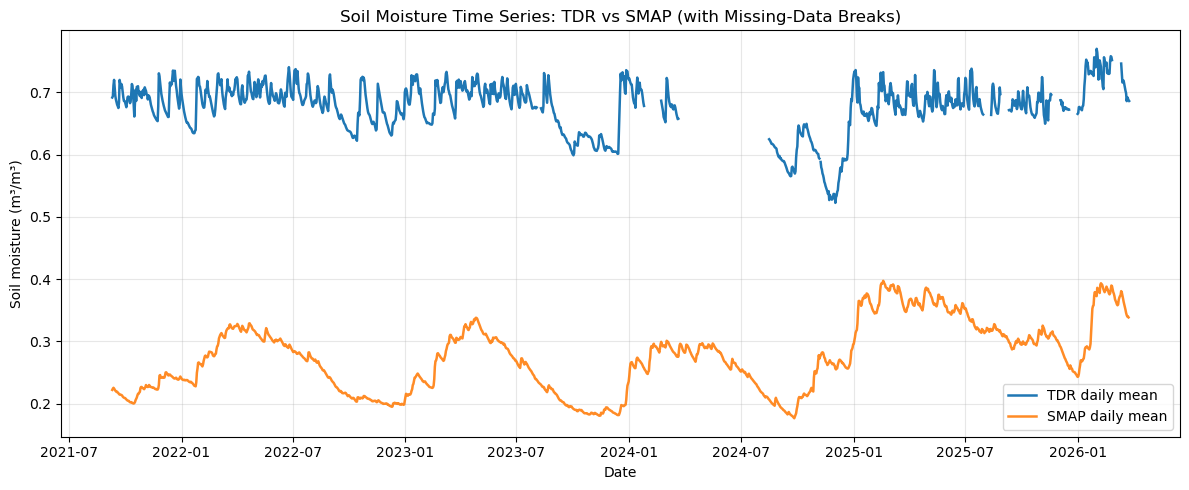

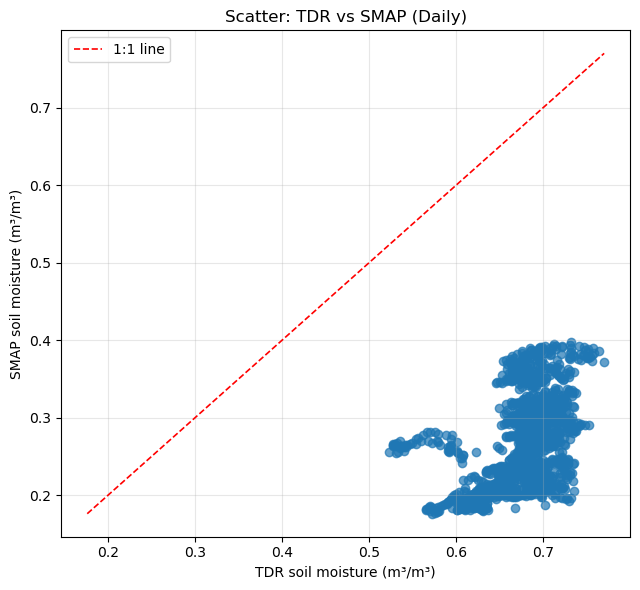

,Date,tdr_soil_moisture,smap_soil_moisture
0,2021-09-10,0.691829,0.222071
1,2021-09-11,0.693932,0.224030
2,2021-09-12,0.711466,0.225418
3,2021-09-13,0.720153,0.224245
4,2021-09-14,0.706234,0.222496


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
tdr_clean_path = r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv"
smap_path = r"TDR_data\SMAP_RZ_clean.csv"

# Load TDR daily mean (already cleaned)
tdr = pd.read_csv(tdr_clean_path, parse_dates=["Date"])
tdr["Date"] = pd.to_datetime(tdr["Date"]).dt.normalize()
tdr = tdr[["Date", "VW_mean_all_sensors"]].dropna().sort_values("Date")

# Load SMAP and aggregate to daily mean to match TDR frequency
smap = pd.read_csv(smap_path, parse_dates=["datetime"])
smap["Date"] = pd.to_datetime(smap["datetime"]).dt.normalize()
smap_daily = (
    smap.groupby("Date", as_index=False)["soil_moisture"]
        .mean()
        .sort_values("Date")
)

# Inner join keeps only overlapping dates for fair comparison metrics
comparison_raw = pd.merge(tdr, smap_daily, on="Date", how="inner")
comparison_raw = comparison_raw.rename(columns={
    "VW_mean_all_sensors": "tdr_soil_moisture",
    "soil_moisture": "smap_soil_moisture"
})

# Quality control: keep physically plausible volumetric soil moisture [0, 1]
qc_mask = (
    comparison_raw["tdr_soil_moisture"].between(0, 1)
    & comparison_raw["smap_soil_moisture"].between(0, 1)
)
comparison = comparison_raw[qc_mask].copy()
removed = len(comparison_raw) - len(comparison)

# Metrics
r = comparison["tdr_soil_moisture"].corr(comparison["smap_soil_moisture"])
rmse = np.sqrt(np.mean((comparison["smap_soil_moisture"] - comparison["tdr_soil_moisture"]) ** 2))
bias = np.mean(comparison["smap_soil_moisture"] - comparison["tdr_soil_moisture"])

print(f"Overlapping days before QC: {len(comparison_raw)}")
print(f"Rows removed by QC: {removed}")
print(f"Overlapping days used: {len(comparison)}")
print(f"Correlation (R): {r:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Bias (SMAP - TDR): {bias:.4f}")

# Save merged comparison table for reporting
comparison_out = r"resultados\comparison_smap_vs_tdr_daily.csv"
comparison.to_csv(comparison_out, index=False)
print(f"Saved comparison table to: {comparison_out}")

# Build continuous daily timeline to create visible breaks for missing data
plot_start = min(tdr["Date"].min(), smap_daily["Date"].min())
plot_end = max(tdr["Date"].max(), smap_daily["Date"].max())
full_timeline = pd.date_range(plot_start, plot_end, freq="D")

# For plotting, also convert out-of-range values to NaN so they appear as breaks
tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src["VW_mean_all_sensors"].between(0, 1), "VW_mean_all_sensors"] = np.nan
smap_plot_src = smap_daily.copy()
smap_plot_src.loc[~smap_plot_src["soil_moisture"].between(0, 1), "soil_moisture"] = np.nan

tdr_plot = tdr_plot_src.set_index("Date").reindex(full_timeline)["VW_mean_all_sensors"]
smap_plot = smap_plot_src.set_index("Date").reindex(full_timeline)["soil_moisture"]

print(f"TDR missing/invalid days shown as breaks: {tdr_plot.isna().sum()}")
print(f"SMAP missing/invalid days shown as breaks: {smap_plot.isna().sum()}")

# Time series plot with breaks on missing or invalid data
plt.figure(figsize=(12, 5))
plt.plot(full_timeline, tdr_plot, label="TDR daily mean", linewidth=1.8)
plt.plot(full_timeline, smap_plot, label="SMAP daily mean", linewidth=1.8, alpha=0.9)
plt.title("Soil Moisture Time Series: TDR vs SMAP (with Missing-Data Breaks)")
plt.xlabel("Date")
plt.ylabel("Soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot with 1:1 line (QC-filtered overlap only)
plt.figure(figsize=(6.5, 6))
plt.scatter(comparison["tdr_soil_moisture"], comparison["smap_soil_moisture"], alpha=0.7)
min_val = min(comparison["tdr_soil_moisture"].min(), comparison["smap_soil_moisture"].min())
max_val = max(comparison["tdr_soil_moisture"].max(), comparison["smap_soil_moisture"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.2, label="1:1 line")
plt.title("Scatter: TDR vs SMAP (Daily)")
plt.xlabel("TDR soil moisture (m³/m³)")
plt.ylabel("SMAP soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

comparison.head()

Overlap-only SMAP vs TDR
Days used: 1411
Correlation (R): 0.4664
RMSE: 0.4063
Bias (SMAP - TDR): -0.4027
Saved overlap-only table to: resultados\comparison_smap_vs_tdr_overlap_only.csv
Missing days shown as breaks (within overlap period): 247


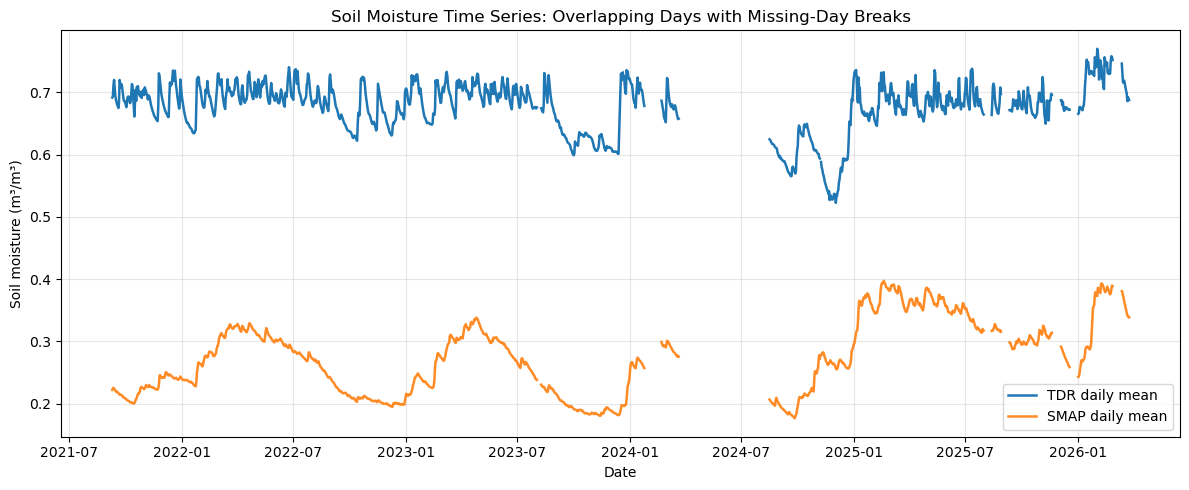

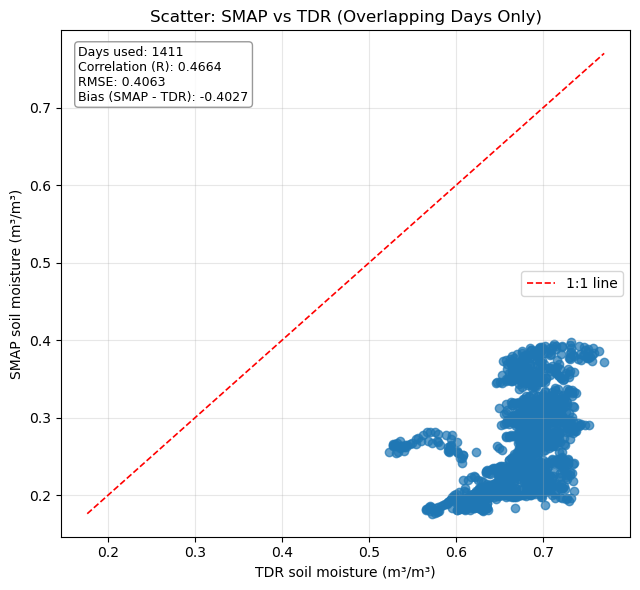

,Date,tdr_soil_moisture,smap_soil_moisture
0,2021-09-10,0.691829,0.222071
1,2021-09-11,0.693932,0.224030
2,2021-09-12,0.711466,0.225418
3,2021-09-13,0.720153,0.224245
4,2021-09-14,0.706234,0.222496


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Overlap-only analysis: keep only dates present in both datasets
tdr_clean_path = r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv"
smap_path = r"TDR_data\SMAP_RZ_clean.csv"

tdr = pd.read_csv(tdr_clean_path, parse_dates=["Date"])
tdr["Date"] = pd.to_datetime(tdr["Date"]).dt.normalize()
tdr = tdr[["Date", "VW_mean_all_sensors"]].rename(columns={"VW_mean_all_sensors": "tdr_soil_moisture"})

smap = pd.read_csv(smap_path, parse_dates=["datetime"])
smap["Date"] = pd.to_datetime(smap["datetime"]).dt.normalize()
smap_daily = smap.groupby("Date", as_index=False)["soil_moisture"].mean()
smap_daily = smap_daily.rename(columns={"soil_moisture": "smap_soil_moisture"})

# Inner join = overlapping days only
overlap = pd.merge(tdr, smap_daily, on="Date", how="inner").sort_values("Date")

# Keep only physically plausible values for both sensors
overlap = overlap[
    overlap["tdr_soil_moisture"].between(0, 1)
    & overlap["smap_soil_moisture"].between(0, 1)
]

# Metrics on overlapping days
r_overlap = overlap["tdr_soil_moisture"].corr(overlap["smap_soil_moisture"])
rmse_overlap = np.sqrt(np.mean((overlap["smap_soil_moisture"] - overlap["tdr_soil_moisture"]) ** 2))
bias_overlap = np.mean(overlap["smap_soil_moisture"] - overlap["tdr_soil_moisture"])

print("Overlap-only SMAP vs TDR")
print(f"Days used: {len(overlap)}")
print(f"Correlation (R): {r_overlap:.4f}")
print(f"RMSE: {rmse_overlap:.4f}")
print(f"Bias (SMAP - TDR): {bias_overlap:.4f}")

overlap_out = r"resultados\comparison_smap_vs_tdr_overlap_only.csv"
overlap.to_csv(overlap_out, index=False)
print(f"Saved overlap-only table to: {overlap_out}")

# Build full timeline over overlap period so missing days are shown as breaks
overlap_start = overlap["Date"].min()
overlap_end = overlap["Date"].max()
overlap_timeline = pd.date_range(overlap_start, overlap_end, freq="D")

tdr_overlap_plot = overlap.set_index("Date").reindex(overlap_timeline)["tdr_soil_moisture"]
smap_overlap_plot = overlap.set_index("Date").reindex(overlap_timeline)["smap_soil_moisture"]

print(f"Missing days shown as breaks (within overlap period): {tdr_overlap_plot.isna().sum()}")

# Time series for overlap-only days with breaks for missing dates
plt.figure(figsize=(12, 5))
plt.plot(overlap_timeline, tdr_overlap_plot, label="TDR daily mean", linewidth=1.8)
plt.plot(overlap_timeline, smap_overlap_plot, label="SMAP daily mean", linewidth=1.8, alpha=0.9)
plt.title("Soil Moisture Time Series: Overlapping Days with Missing-Day Breaks")
plt.xlabel("Date")
plt.ylabel("Soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot with 1:1 line
plt.figure(figsize=(6.5, 6))
plt.scatter(overlap["tdr_soil_moisture"], overlap["smap_soil_moisture"], alpha=0.7)
min_val = min(overlap["tdr_soil_moisture"].min(), overlap["smap_soil_moisture"].min())
max_val = max(overlap["tdr_soil_moisture"].max(), overlap["smap_soil_moisture"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.2, label="1:1 line")
stats_text = (
    f"Days used: {len(overlap)}\n"
    f"Correlation (R): {r_overlap:.4f}\n"
    f"RMSE: {rmse_overlap:.4f}\n"
    f"Bias (SMAP - TDR): {bias_overlap:.4f}"
)
ax = plt.gca()
ax.text(
    0.03,
    0.97,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "gray"},
)
plt.title("Scatter: SMAP vs TDR (Overlapping Days Only)")
plt.xlabel("TDR soil moisture (m³/m³)")
plt.ylabel("SMAP soil moisture (m³/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

overlap.head()

Missing days shown as breaks in overlap z-score plot: 247


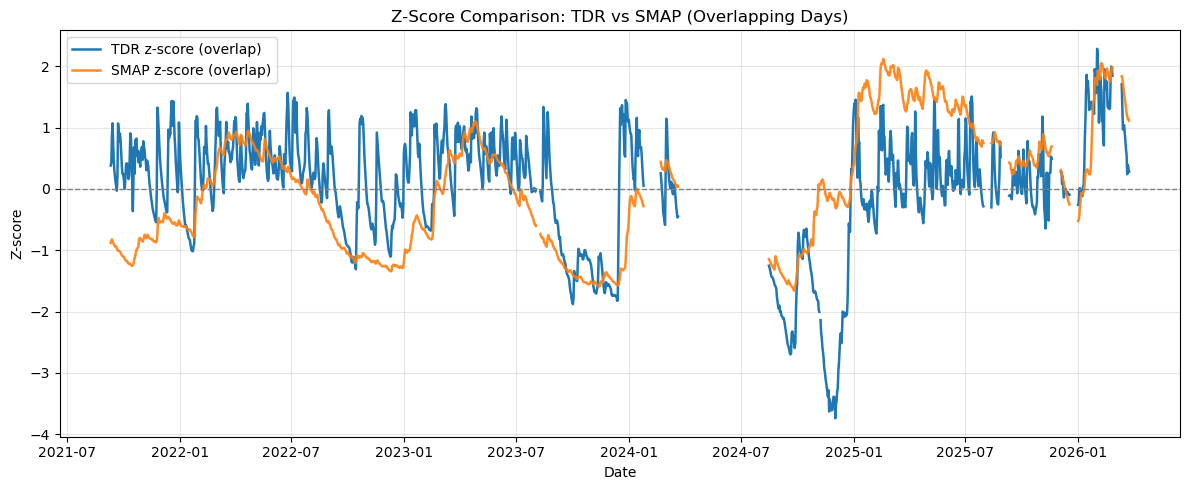

Missing/invalid TDR days shown as breaks in full-SMAP z-score plot: 247


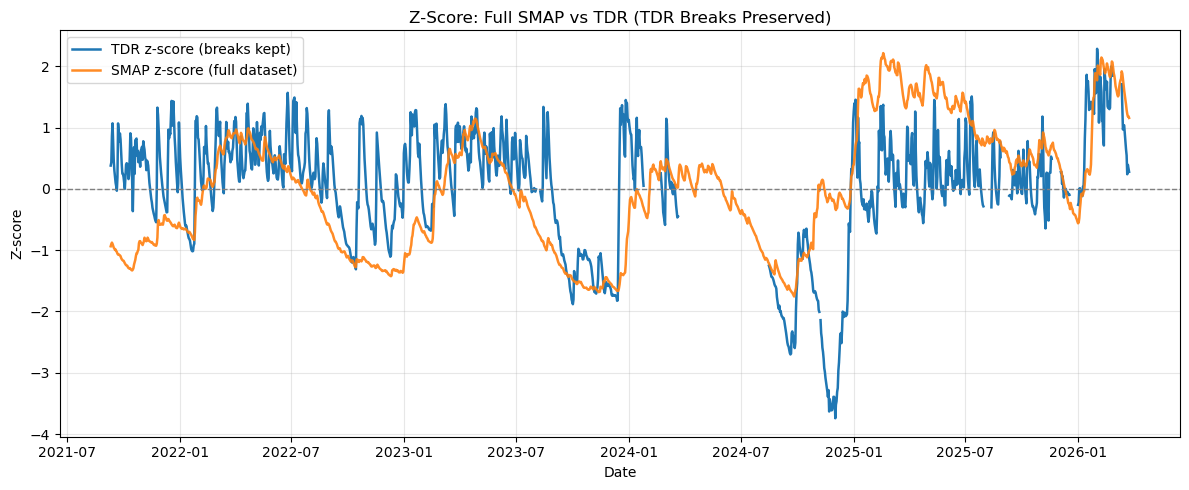

,Date,tdr_z,smap_z
0,2021-09-10,0.380729,-0.880222
1,2021-09-11,0.431930,-0.846670
2,2021-09-12,0.858747,-0.822900
3,2021-09-13,1.070219,-0.842994
4,2021-09-14,0.731391,-0.872950


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Plot 1: overlap-only z-score with breaks ----------
if "overlap" not in globals():
    overlap = pd.read_csv(r"resultados\comparison_smap_vs_tdr_overlap_only.csv", parse_dates=["Date"])
else:
    overlap = overlap.copy()

overlap = overlap.sort_values("Date")

tdr_overlap = overlap["tdr_soil_moisture"]
smap_overlap = overlap["smap_soil_moisture"]

tdr_z = (tdr_overlap - tdr_overlap.mean()) / tdr_overlap.std()
smap_z = (smap_overlap - smap_overlap.mean()) / smap_overlap.std()

z_df = pd.DataFrame({
    "Date": overlap["Date"],
    "tdr_z": tdr_z,
    "smap_z": smap_z
}).set_index("Date")
z_timeline = pd.date_range(z_df.index.min(), z_df.index.max(), freq="D")
z_plot = z_df.reindex(z_timeline)

print(f"Missing days shown as breaks in overlap z-score plot: {z_plot['tdr_z'].isna().sum()}")

plt.figure(figsize=(12, 5))
plt.plot(z_timeline, z_plot["tdr_z"], label="TDR z-score (overlap)", linewidth=1.8)
plt.plot(z_timeline, z_plot["smap_z"], label="SMAP z-score (overlap)", linewidth=1.8, alpha=0.9)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Z-Score Comparison: TDR vs SMAP (Overlapping Days)")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Plot 2: full SMAP z-score + TDR breaks retained ----------
# Full SMAP daily series
smap_full = pd.read_csv(r"TDR_data\SMAP_RZ_clean.csv", parse_dates=["datetime"])
smap_full["Date"] = pd.to_datetime(smap_full["datetime"]).dt.normalize()
smap_full_daily = smap_full.groupby("Date", as_index=False)["soil_moisture"].mean().sort_values("Date")
smap_full_daily["smap_z_full"] = (
    smap_full_daily["soil_moisture"] - smap_full_daily["soil_moisture"].mean()
 ) / smap_full_daily["soil_moisture"].std()

# TDR from clean series + explicit missing-date list to preserve breaks
tdr_clean_full = pd.read_csv(
    r"resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv",
    parse_dates=["Date"]
)
tdr_clean_full["Date"] = pd.to_datetime(tdr_clean_full["Date"]).dt.normalize()
tdr_clean_full = tdr_clean_full[["Date", "VW_mean_all_sensors"]].drop_duplicates(subset="Date").sort_values("Date")

missing_days = pd.read_csv(
    r"resultados\missing_dates_daily_mean_all_sensors.csv",
    parse_dates=["date"]
)
missing_days["date"] = pd.to_datetime(missing_days["date"]).dt.normalize()
missing_set = set(missing_days["date"])

tdr_vals = tdr_clean_full["VW_mean_all_sensors"].where(
    tdr_clean_full["VW_mean_all_sensors"].between(0, 1)
 )
tdr_clean_full["tdr_z_full"] = (tdr_vals - tdr_vals.mean()) / tdr_vals.std()

# Use full SMAP date span and reindex TDR so TDR gaps stay visible
timeline_full_smap = pd.date_range(
    smap_full_daily["Date"].min(),
    smap_full_daily["Date"].max(),
    freq="D"
 )
smap_full_plot = smap_full_daily.set_index("Date").reindex(timeline_full_smap)["smap_z_full"]
tdr_full_plot = tdr_clean_full.set_index("Date").reindex(timeline_full_smap)["tdr_z_full"]

# Enforce known missing TDR dates as NaN breaks
tdr_full_plot.loc[tdr_full_plot.index.isin(missing_set)] = pd.NA

print(f"Missing/invalid TDR days shown as breaks in full-SMAP z-score plot: {tdr_full_plot.isna().sum()}")

plt.figure(figsize=(12, 5))
plt.plot(timeline_full_smap, tdr_full_plot, label="TDR z-score (breaks kept)", linewidth=1.8)
plt.plot(timeline_full_smap, smap_full_plot, label="SMAP z-score (full dataset)", linewidth=1.8, alpha=0.9)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Z-Score: Full SMAP vs TDR (TDR Breaks Preserved)")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

z_plot.reset_index().rename(columns={"index": "Date"}).head()